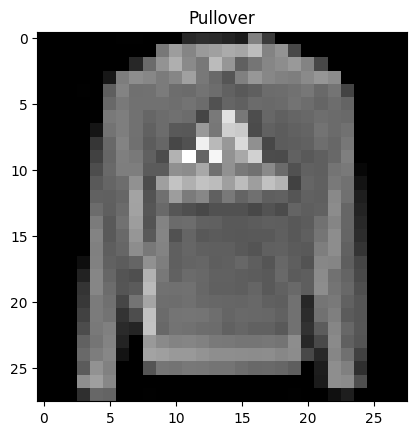

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 加载数据集
data_folder = './FMNIST_data'
train_data = datasets.FashionMNIST(data_folder, download=False, train=True, transform=None)
test_data = datasets.FashionMNIST(data_folder, download=False, train=False, transform=None)

imgs = train_data.data
labels = train_data.targets

class FMINISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)
    
def get_data():
    data = FMINISTDataset(imgs, labels)
    partial_data = DataLoader(data, batch_size=64, shuffle=True)
    return partial_data


ix = 24150
plt.imshow(imgs[ix], cmap='gray')
plt.title(datasets.FashionMNIST.classes[labels[ix]])
plt.show()


